In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries ready!")

All libraries ready!


In [2]:
df = pd.read_csv('../data/breaches_clean.csv')
print("Data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Data loaded!
Shape: (295, 5)
Columns: ['entity', 'year', 'records', 'organization_type', 'method']


,entity,year,records,organization_type,method
0,21st Century Oncology,2016,2200000,healthcare,Hacked
1,500px,2020,14870304,social networking,Hacked
2,Accendo Insurance Co.,2020,175350,healthcare,Poor Security
3,Adobe Systems Incorporated,2013,152000000,tech,Hacked
4,Adobe Inc.,2019,7500000,tech,Poor Security


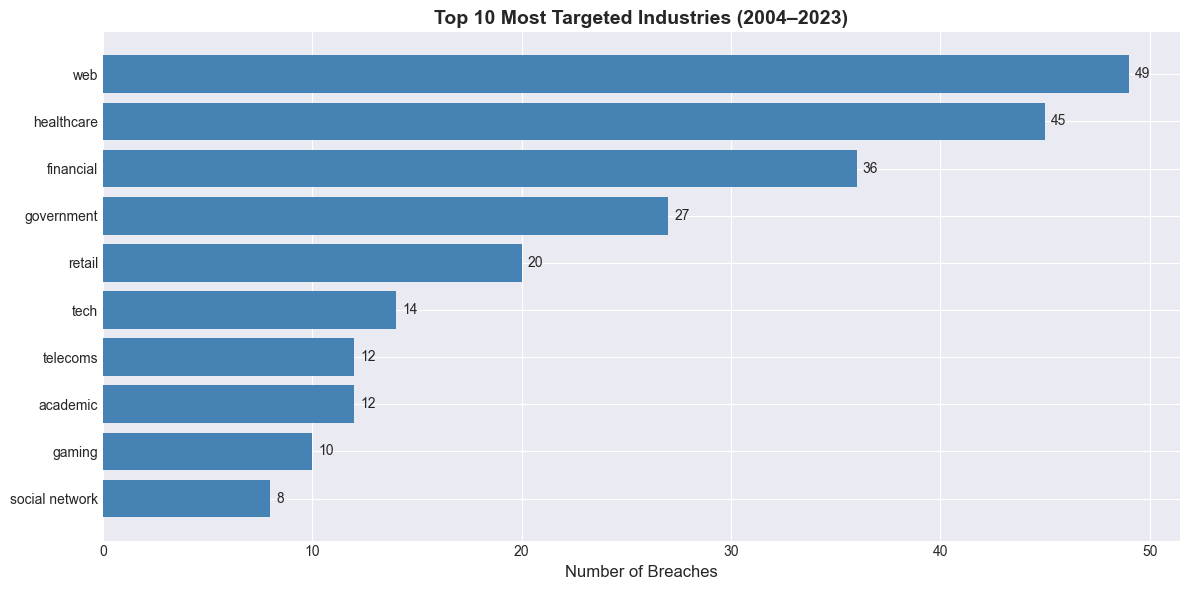

Chart 1 saved!


In [3]:
top_sectors = df['organization_type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_sectors.index[::-1], top_sectors.values[::-1], color='steelblue')
plt.xlabel('Number of Breaches', fontsize=12)
plt.title('Top 10 Most Targeted Industries (2004–2023)', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_sectors.values[::-1]):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/chart1_top_industries.png', dpi=150)
plt.show()
print("Chart 1 saved!")

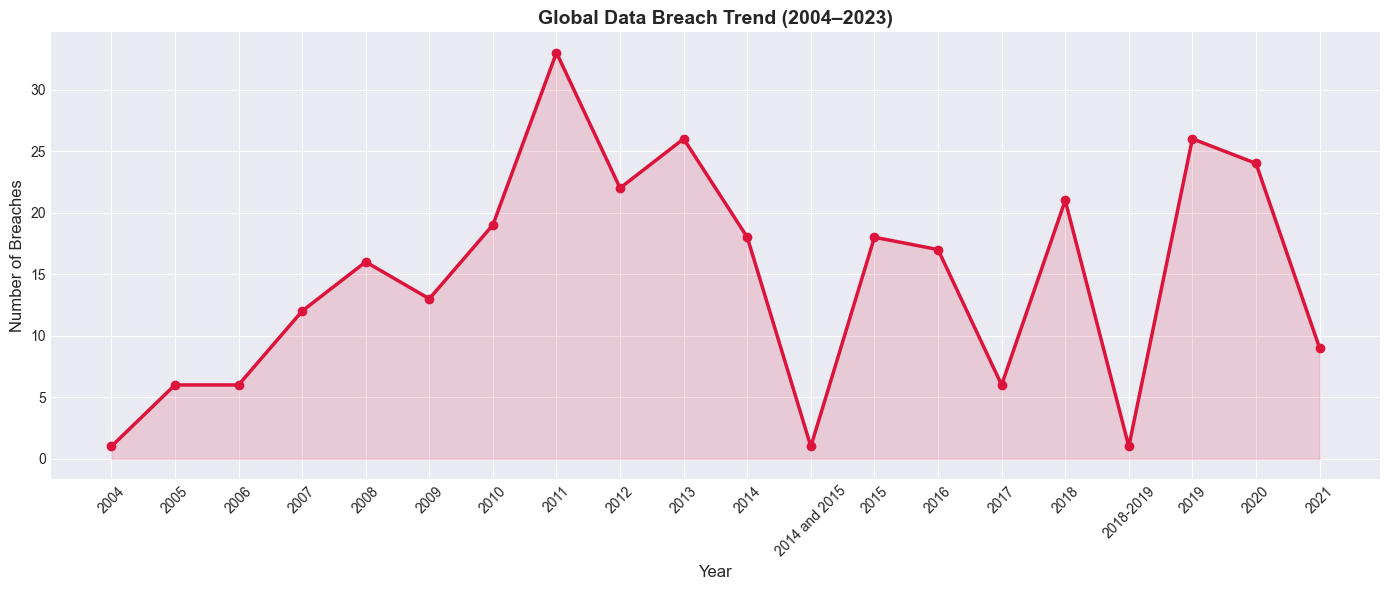

Chart 2 saved!


In [4]:
yearly = df.groupby('year').size().reset_index(name='breach_count')

plt.figure(figsize=(14, 6))
plt.plot(yearly['year'], yearly['breach_count'], marker='o',
         linewidth=2.5, color='crimson', markersize=6)
plt.fill_between(yearly['year'], yearly['breach_count'], alpha=0.15, color='crimson')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Breaches', fontsize=12)
plt.title('Global Data Breach Trend (2004–2023)', fontsize=14, fontweight='bold')
plt.xticks(yearly['year'], rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart2_yearly_trend.png', dpi=150)
plt.show()
print("Chart 2 saved!")

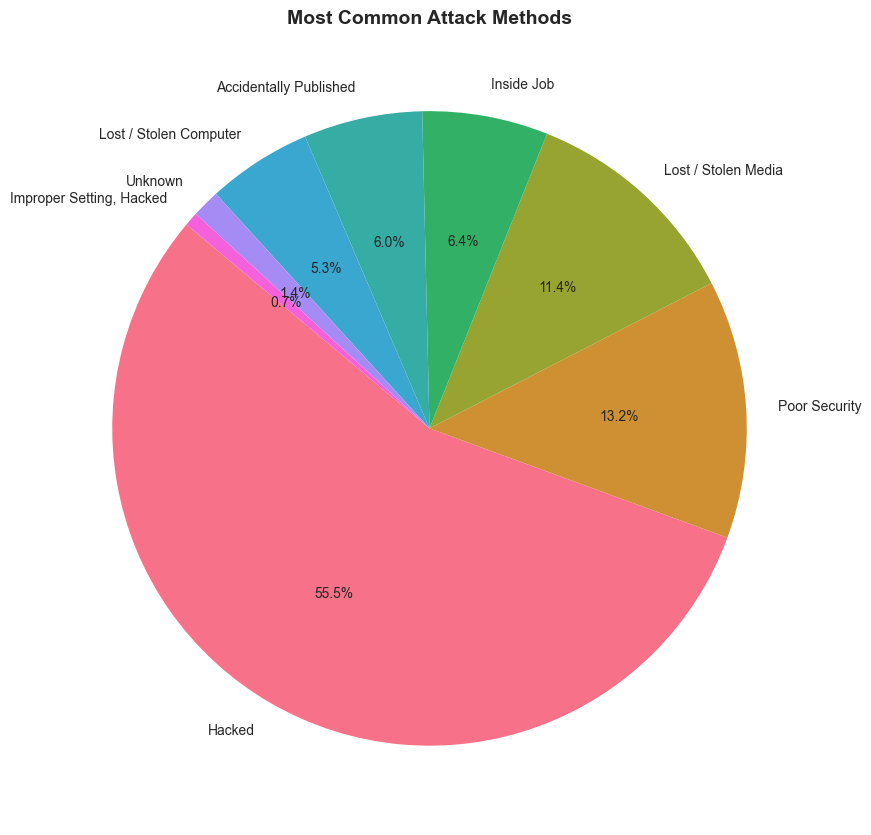

Chart 3 saved!


In [5]:
method_counts = df['method'].value_counts().head(8)

plt.figure(figsize=(9, 9))
plt.pie(method_counts.values, labels=method_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette("husl", len(method_counts)))
plt.title('Most Common Attack Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart3_attack_methods.png', dpi=150)
plt.show()
print("Chart 3 saved!")

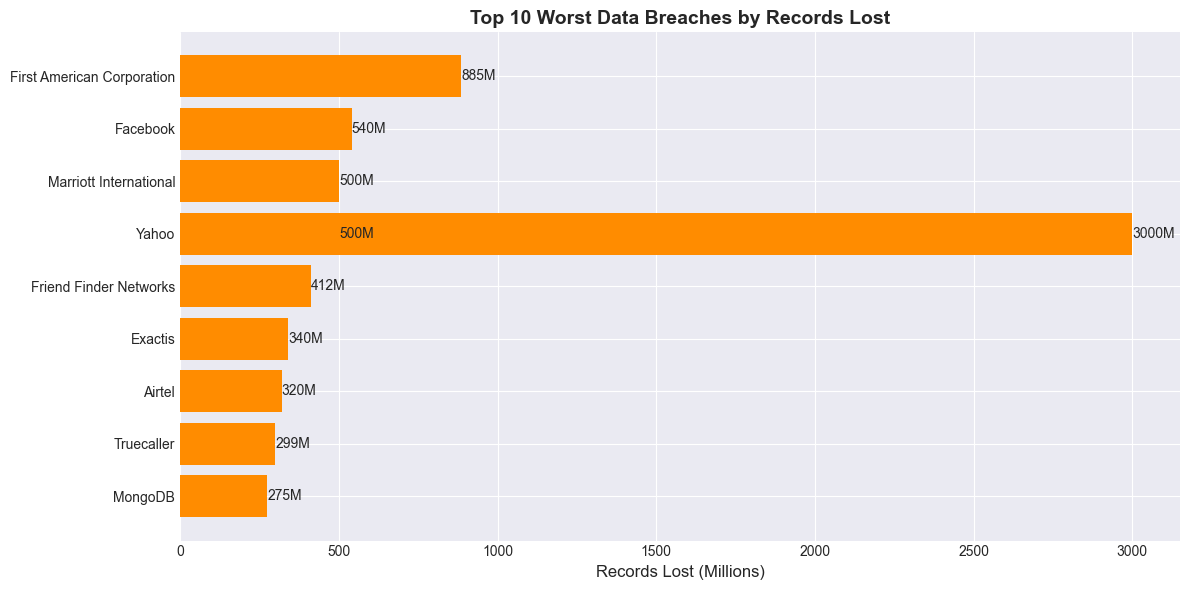

Chart 4 saved!


In [6]:
df['records'] = pd.to_numeric(df['records'], errors='coerce')
top_breaches = df.nlargest(10, 'records')[['entity', 'records', 'year']]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_breaches['entity'][::-1],
                top_breaches['records'][::-1] / 1e6, color='darkorange')
plt.xlabel('Records Lost (Millions)', fontsize=12)
plt.title('Top 10 Worst Data Breaches by Records Lost', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_breaches['records'][::-1] / 1e6):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/chart4_worst_breaches.png', dpi=150)
plt.show()
print("Chart 4 saved!")

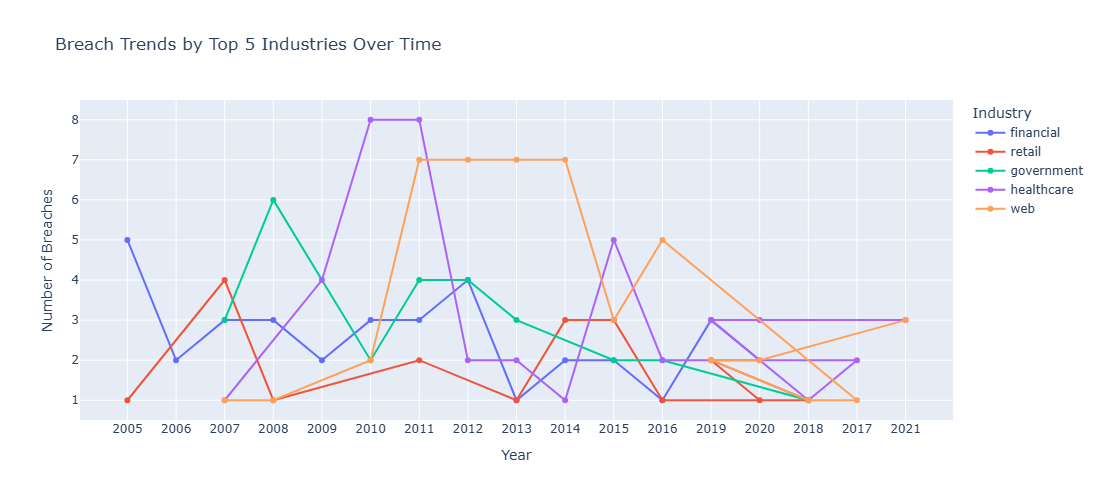

Interactive chart saved!


In [7]:
yearly_sector = df.groupby(['year', 'organization_type']).size().reset_index(name='count')
top5_sectors = df['organization_type'].value_counts().head(5).index
filtered = yearly_sector[yearly_sector['organization_type'].isin(top5_sectors)]

fig = px.line(filtered, x='year', y='count', color='organization_type',
              title='Breach Trends by Top 5 Industries Over Time',
              labels={'count': 'Number of Breaches',
                      'year': 'Year',
                      'organization_type': 'Industry'},
              markers=True)

fig.update_layout(height=500)
fig.write_html('../outputs/chart5_interactive.html')
fig.show()
print("Interactive chart saved!")

In [8]:
print("=" * 50)
print("PHASE 3 COMPLETE!")
print("=" * 50)
print(f"Total records analyzed: {len(df)}")
print(f"Years covered: {df['year'].min()} to {df['year'].max()}")
print(f"Industries covered: {df['organization_type'].nunique()}")
print(f"Attack types found: {df['method'].nunique()}")
print(f"Most targeted industry: {df['organization_type'].value_counts().index[0]}")
print(f"Most common attack: {df['method'].value_counts().index[0]}")
print("\nCharts saved in outputs/ folder:")
print("  chart1_top_industries.png")
print("  chart2_yearly_trend.png")
print("  chart3_attack_methods.png")
print("  chart4_worst_breaches.png")
print("  chart5_interactive.html")

PHASE 3 COMPLETE!
Total records analyzed: 295
Years covered: 2004 to 2021
Industries covered: 54
Attack types found: 21
Most targeted industry: web
Most common attack: Hacked

Charts saved in outputs/ folder:
  chart1_top_industries.png
  chart2_yearly_trend.png
  chart3_attack_methods.png
  chart4_worst_breaches.png
  chart5_interactive.html


In [9]:
import sqlite3

conn = sqlite3.connect('../data/breaches.db')
df.to_sql('breaches', conn, if_exists='replace', index=False)
print("Database created successfully!")
print("Table 'breaches' loaded with", len(df), "rows")

Database created successfully!
Table 'breaches' loaded with 295 rows


In [1]:
import sqlite3

conn = sqlite3.connect('../data/breaches.db')
df.to_sql('breaches', conn, if_exists='replace', index=False)
print("Database created successfully!")
print("Table 'breaches' loaded with", len(df), "rows")

NameError: name 'df' is not defined

In [2]:
import sqlite3
import pandas as pd

df = pd.read_csv('../data/breaches_clean.csv')
conn = sqlite3.connect('../data/breaches.db')
df.to_sql('breaches', conn, if_exists='replace', index=False)
print("Database ready!")
print("Rows:", len(df))

Database ready!
Rows: 295


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/breaches.db')

# Query 1 - Total breaches per industry
print("=" * 50)
print("QUERY 1: Total breaches per industry")
print("=" * 50)
q1 = pd.read_sql_query("""
    SELECT organization_type, 
           COUNT(*) as total_breaches
    FROM breaches
    GROUP BY organization_type
    ORDER BY total_breaches DESC
    LIMIT 10
""", conn)
print(q1.to_string(index=False))

# Query 2 - Breaches per year
print("\n" + "=" * 50)
print("QUERY 2: Breaches per year")
print("=" * 50)
q2 = pd.read_sql_query("""
    SELECT year,
           COUNT(*) as breach_count
    FROM breaches
    GROUP BY year
    ORDER BY year
""", conn)
print(q2.to_string(index=False))

# Query 3 - Top 5 attack methods
print("\n" + "=" * 50)
print("QUERY 3: Top 5 attack methods")
print("=" * 50)
q3 = pd.read_sql_query("""
    SELECT method,
           COUNT(*) as total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM breaches), 2) as percentage
    FROM breaches
    GROUP BY method
    ORDER BY total DESC
    LIMIT 5
""", conn)
print(q3.to_string(index=False))

# Query 4 - Top 10 worst breaches
print("\n" + "=" * 50)
print("QUERY 4: Top 10 worst breaches by records lost")
print("=" * 50)
q4 = pd.read_sql_query("""
    SELECT entity, year, records, method
    FROM breaches
    ORDER BY CAST(records AS INTEGER) DESC
    LIMIT 10
""", conn)
print(q4.to_string(index=False))

# Query 5 - Running total using window function
print("\n" + "=" * 50)
print("QUERY 5: Running total of breaches by year")
print("=" * 50)
q5 = pd.read_sql_query("""
    SELECT year,
           COUNT(*) as yearly_count,
           SUM(COUNT(*)) OVER (ORDER BY year) as running_total
    FROM breaches
    GROUP BY year
    ORDER BY year
""", conn)
print(q5.to_string(index=False))

# Query 6 - % share per sector
print("\n" + "=" * 50)
print("QUERY 6: Percentage share of breaches per sector")
print("=" * 50)
q6 = pd.read_sql_query("""
    SELECT organization_type,
           COUNT(*) as breaches,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM breaches), 2) as percentage
    FROM breaches
    GROUP BY organization_type
    ORDER BY breaches DESC
    LIMIT 10
""", conn)
print(q6.to_string(index=False))

conn.close()
print("\n" + "=" * 50)
print("ALL SQL QUERIES COMPLETE!")
print("=" * 50)

QUERY 1: Total breaches per industry
organization_type  total_breaches
              web              49
       healthcare              45
        financial              36
       government              27
           retail              20
             tech              14
         telecoms              12
         academic              12
           gaming              10
   social network               8

QUERY 2: Breaches per year
         year  breach_count
         2004             1
         2005             6
         2006             6
         2007            12
         2008            16
         2009            13
         2010            19
         2011            33
         2012            22
         2013            26
         2014            18
2014 and 2015             1
         2015            18
         2016            17
         2017             6
         2018            21
    2018-2019             1
         2019            26
         2020            24
 